In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mmumairkhattak/roman-urdu-sentiment-dataset-2026-nlp-and-tc/data_dictionary.csv
/kaggle/input/datasets/mmumairkhattak/roman-urdu-sentiment-dataset-2026-nlp-and-tc/roman_urdu_sentiment_notebook.ipynb
/kaggle/input/datasets/mmumairkhattak/roman-urdu-sentiment-dataset-2026-nlp-and-tc/roman_urdu_sentiment_dataset.csv


# Roman Urdu Sentiment Dataset 2026

This notebook explores Roman Urdu text samples and builds a baseline sentiment classification model.

**2. Import Libraries**

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

**3. Find Dataset Path**

In [3]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mmumairkhattak/roman-urdu-sentiment-dataset-2026-nlp-and-tc/data_dictionary.csv
/kaggle/input/datasets/mmumairkhattak/roman-urdu-sentiment-dataset-2026-nlp-and-tc/roman_urdu_sentiment_notebook.ipynb
/kaggle/input/datasets/mmumairkhattak/roman-urdu-sentiment-dataset-2026-nlp-and-tc/roman_urdu_sentiment_dataset.csv


**4. Load Dataset**

In [4]:
csv_path = None

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename == 'roman_urdu_sentiment_dataset.csv':
            csv_path = os.path.join(dirname, filename)

print('Dataset path:', csv_path)

df = pd.read_csv(csv_path)
df.head()

Dataset path: /kaggle/input/datasets/mmumairkhattak/roman-urdu-sentiment-dataset-2026-nlp-and-tc/roman_urdu_sentiment_dataset.csv


,Text_ID,Text,Sentiment,Sentiment_Score,Subjectivity_Score,Text_Length,Word_Count,Source,Domain,Language
0,RUTXT000001,delivery fast thi aur product acha tha,Positive,0.506,0.848,38,7,Social Media,Retail,Roman Urdu
1,RUTXT000002,ye product theek hai,Neutral,0.086,0.170,20,4,App Review,Education,Roman Urdu
2,RUTXT000003,delivery late thi aur product kharab tha,Negative,-0.452,0.608,40,7,Customer Feedback,Food,Roman Urdu
3,RUTXT000004,service normal thi,Neutral,-0.106,0.405,18,3,Survey,Travel,Roman Urdu
4,RUTXT000005,mujhe ye service pasand nahi ayi,Negative,-0.465,0.537,32,6,Customer Feedback,Technology,Roman Urdu


**5. Dataset Overview**

In [5]:
df.shape

(30000, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Text_ID             30000 non-null  object 
 1   Text                30000 non-null  object 
 2   Sentiment           30000 non-null  object 
 3   Sentiment_Score     30000 non-null  float64
 4   Subjectivity_Score  30000 non-null  float64
 5   Text_Length         30000 non-null  int64  
 6   Word_Count          30000 non-null  int64  
 7   Source              30000 non-null  object 
 8   Domain              30000 non-null  object 
 9   Language            30000 non-null  object 
dtypes: float64(2), int64(2), object(6)
memory usage: 2.3+ MB


In [7]:
df.isnull().sum()

Text_ID               0
Text                  0
Sentiment             0
Sentiment_Score       0
Subjectivity_Score    0
Text_Length           0
Word_Count            0
Source                0
Domain                0
Language              0
dtype: int64

In [8]:
df.isnull().sum()

Text_ID               0
Text                  0
Sentiment             0
Sentiment_Score       0
Subjectivity_Score    0
Text_Length           0
Word_Count            0
Source                0
Domain                0
Language              0
dtype: int64

**6. Sentiment Distribution**

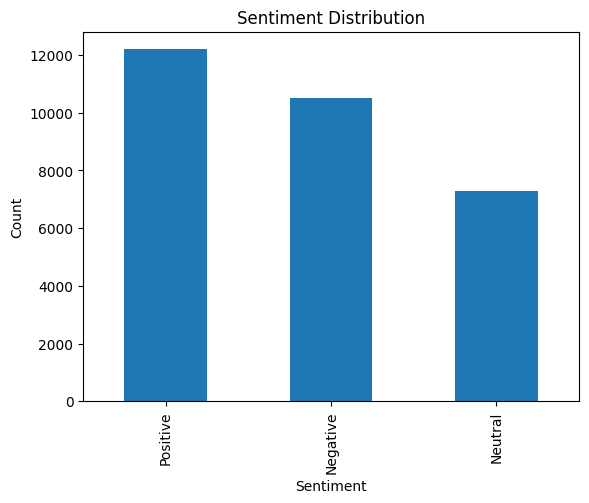

In [9]:
df['Sentiment'].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

**7. Word Count Analysis**

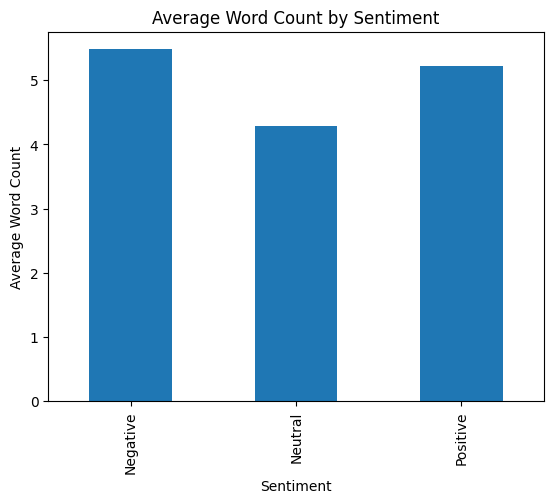

In [10]:
df.groupby('Sentiment')['Word_Count'].mean().plot(kind='bar')
plt.title('Average Word Count by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Word Count')
plt.show()

**8. Text Length Analysis**

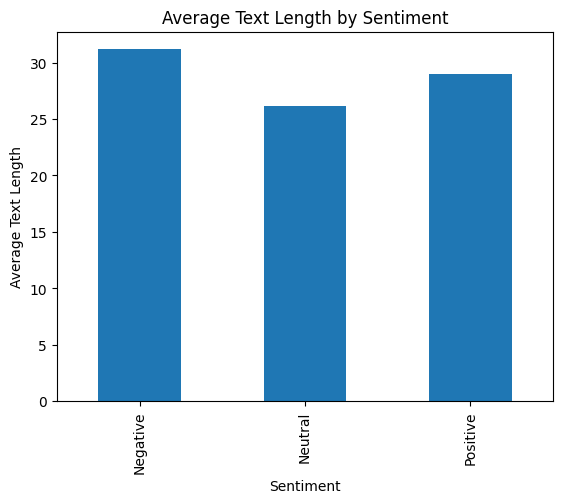

In [11]:
df.groupby('Sentiment')['Text_Length'].mean().plot(kind='bar')
plt.title('Average Text Length by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Text Length')
plt.show()

**9. Domain Analysis**

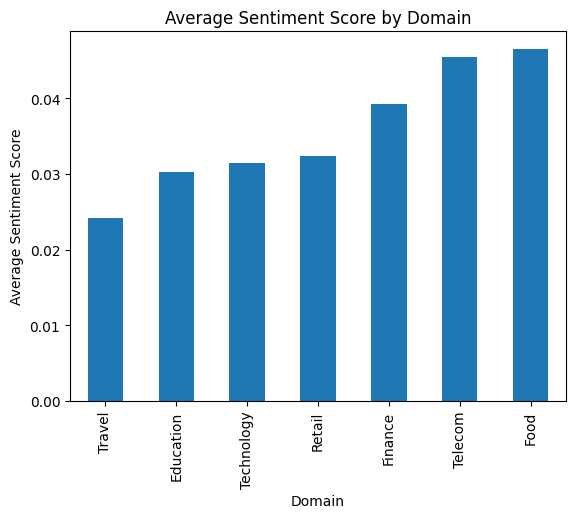

In [12]:
df.groupby('Domain')['Sentiment_Score'].mean().sort_values().plot(kind='bar')
plt.title('Average Sentiment Score by Domain')
plt.xlabel('Domain')
plt.ylabel('Average Sentiment Score')
plt.show()

**10. Sentiment Classification Model**

In [13]:
X = df['Text']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('classifier', LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)
pred = model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 1.0
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      2102
     Neutral       1.00      1.00      1.00      1458
    Positive       1.00      1.00      1.00      2440

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



**11. Final Conclusion**

## Results and Conclusion

This analysis explored the Roman Urdu Sentiment Dataset 2026.

Key findings include:

- The dataset contains Positive, Negative, and Neutral sentiment classes.
- Sentiment score helps measure polarity.
- Word count and text length support text structure analysis.
- Domain-level analysis shows sentiment variation across different categories.
- A baseline TF-IDF and Logistic Regression model can classify Roman Urdu sentiment labels.

This dataset is suitable for Roman Urdu sentiment analysis, NLP classification, text mining, machine learning education, and AI research.